In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import datetime

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

import matplotlib.pyplot as plt

In [2]:
# Base directory
save_directory = r"try_02"
path = os.path.join(save_directory, "featured_144days.pkl")

df = pd.read_pickle(path)
print("Shape : ", df.shape)
df.head()

Shape :  (1720181, 35)


,step,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud,index,...,INIT_AMOUNT_DEV_TX_24,INIT_TX_COUNT_STEP_6,INIT_TX_COUNT_STEP_12,INIT_TX_COUNT_STEP_24,RECIP_RISK_6,RECIP_TX_COUNT_6,RECIP_RISK_12,RECIP_TX_COUNT_12,RECIP_RISK_24,RECIP_TX_COUNT_24
0,0,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1,0,...,0.00,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0
1,0,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0,1,...,0.00,1,1,1,0.0,0.0,0.0,0.0,0.0,0.0
2,0,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0,2,...,0.00,2,2,2,0.0,0.0,0.0,0.0,0.0,0.0
3,0,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1,3,...,9650.58,2,2,2,0.0,0.0,0.0,0.0,0.0,0.0
4,0,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0,4,...,0.00,4,4,4,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.columns

Index(['step', 'amount', 'initiator', 'oldBalInitiator', 'newBalInitiator',
       'recipient', 'oldBalRecipient', 'newBalRecipient', 'isFraud', 'index',
       'transactionType_DEBIT', 'transactionType_DEPOSIT',
       'transactionType_PAYMENT', 'transactionType_TRANSFER',
       'transactionType_WITHDRAWAL', 'amount_balance_ratio',
       'balance_increase_ratio', 'neg_balance_i', 'balance_error_i',
       'balance_error_r', 'INIT_AVG_AMOUNT_TX_6', 'INIT_AMOUNT_DEV_TX_6',
       'INIT_AVG_AMOUNT_TX_12', 'INIT_AMOUNT_DEV_TX_12',
       'INIT_AVG_AMOUNT_TX_24', 'INIT_AMOUNT_DEV_TX_24',
       'INIT_TX_COUNT_STEP_6', 'INIT_TX_COUNT_STEP_12',
       'INIT_TX_COUNT_STEP_24', 'RECIP_RISK_6', 'RECIP_TX_COUNT_6',
       'RECIP_RISK_12', 'RECIP_TX_COUNT_12', 'RECIP_RISK_24',
       'RECIP_TX_COUNT_24'],
      dtype='object')

In [4]:
df = df.sort_values(["step", "index"]).reset_index(drop=True)

delay = 6

max_step = df["step"].max()

train_end = int(max_step * 0.8)
delay_end = train_end + delay

print("Train ends at step:", train_end)
print("Delay ends at step:", delay_end)

train_df = df[df["step"] <= train_end]
delay_df = df[(df["step"] > train_end) & (df["step"] <= delay_end)]  # not used
test_df = df[df["step"] > delay_end]

Train ends at step: 114
Delay ends at step: 120


In [5]:
drop_cols = [
    "step",
    "recipient",
    "initiator",
    "index"
]

In [6]:
x_train = train_df.drop(columns=drop_cols + ["isFraud"])
y_train = train_df["isFraud"]

x_test = test_df.drop(columns=drop_cols + ["isFraud"])
y_test = test_df["isFraud"]

In [7]:
print("Train : ", x_train.shape)
print("Test : ", x_test.shape)
print("\n")
print("Train frauds : ", y_train.sum())
print("Train fraud rate : ", y_train.mean())
print("\n")
print("Test frauds : ", y_test.sum())
print("Test fraud rate : ", y_test.mean())

Train :  (1361460, 30)
Test :  (303058, 30)


Train frauds :  140466
Train fraud rate :  0.10317306421047992


Test frauds :  27938
Test fraud rate :  0.0921869741105663


## Scale Features
MLP is sensitive to feature scale. We fit the scaler on training data only to avoid data leakage.

In [8]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaling done.")
print("x_train_scaled shape:", x_train_scaled.shape)
print("x_test_scaled shape: ", x_test_scaled.shape)

Scaling done.
x_train_scaled shape: (1361460, 30)
x_test_scaled shape:  (303058, 30)


## Train MLP Models

- **mlp1** — Shallow network (1 hidden layer, 64 units): fast baseline
- **mlp2** — Deeper network (3 hidden layers, 128-64-32): more capacity for complex patterns

Unlike Random Forest, sklearn's `MLPClassifier` does not have a `class_weight` parameter.
The equivalent fix is to pass `sample_weight` in `.fit()`, which assigns a higher penalty
to fraud samples so the model cannot ignore them.

In [9]:
# Compute sample weights — mirrors class_weight='balanced' from Random Forest
# Weight for each class = total_samples / (n_classes * count_of_class)
n_samples = len(y_train)
n_classes = 2
count_0 = (y_train == 0).sum()
count_1 = (y_train == 1).sum()

weight_0 = n_samples / (n_classes * count_0)
weight_1 = n_samples / (n_classes * count_1)

sample_weights = y_train.map({0: weight_0, 1: weight_1}).values

print(f"Non-fraud weight : {weight_0:.4f}")
print(f"Fraud weight     : {weight_1:.4f}")
print(f"Weight ratio     : {weight_1 / weight_0:.1f}x")

Non-fraud weight : 0.5575
Fraud weight     : 4.8462
Weight ratio     : 8.7x


In [10]:
mlp1 = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=True
)

mlp1.fit(x_train_scaled, y_train, sample_weight=sample_weights)
print("\nmlp1 training complete. Iterations:", mlp1.n_iter_)

Iteration 1, loss = 0.30491162
Validation score: 0.879118
Iteration 2, loss = 0.30005041
Validation score: 0.879281
Iteration 3, loss = 0.29918584
Validation score: 0.879355
Iteration 4, loss = 0.29880447
Validation score: 0.879229
Iteration 5, loss = 0.29856748
Validation score: 0.879187
Iteration 6, loss = 0.29831185
Validation score: 0.879179
Iteration 7, loss = 0.29826988
Validation score: 0.879401
Iteration 8, loss = 0.29815816
Validation score: 0.879157
Iteration 9, loss = 0.29805216
Validation score: 0.879357
Iteration 10, loss = 0.29801777
Validation score: 0.879273
Iteration 11, loss = 0.29791458
Validation score: 0.879370
Iteration 12, loss = 0.29798547
Validation score: 0.879305
Iteration 13, loss = 0.29778601
Validation score: 0.879194
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

mlp1 training complete. Iterations: 13


In [11]:
mlp2 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=True
)

mlp2.fit(x_train_scaled, y_train, sample_weight=sample_weights)
print("\nmlp2 training complete. Iterations:", mlp2.n_iter_)

Iteration 1, loss = 0.30182772
Validation score: 0.878793
Iteration 2, loss = 0.29871109
Validation score: 0.879428
Iteration 3, loss = 0.29833431
Validation score: 0.879652
Iteration 4, loss = 0.29814628
Validation score: 0.879739
Iteration 5, loss = 0.29804879
Validation score: 0.879053
Iteration 6, loss = 0.29807162
Validation score: 0.879598
Iteration 7, loss = 0.29797023
Validation score: 0.879650
Iteration 8, loss = 0.29784139
Validation score: 0.879577
Iteration 9, loss = 0.29772786
Validation score: 0.879679
Iteration 10, loss = 0.29776264
Validation score: 0.879651
Iteration 11, loss = 0.29760462
Validation score: 0.879593
Iteration 12, loss = 0.29766307
Validation score: 0.879618
Iteration 13, loss = 0.29768086
Validation score: 0.879641
Iteration 14, loss = 0.29785622
Validation score: 0.879734
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

mlp2 training complete. Iterations: 14


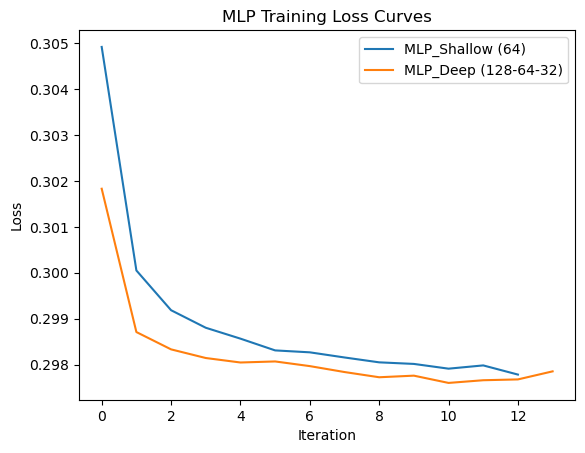

In [12]:
# Plot training loss curves
plt.figure()
plt.plot(mlp1.loss_curve_, label="MLP_Shallow (64)")
plt.plot(mlp2.loss_curve_, label="MLP_Deep (128-64-32)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curves")
plt.legend()
plt.show()

In [13]:
os.makedirs(save_directory, exist_ok=True)

joblib.dump(mlp1, os.path.join(save_directory, "model_mlp_shallow.pkl"))
joblib.dump(mlp2, os.path.join(save_directory, "model_mlp_deep.pkl"))
joblib.dump(scaler, os.path.join(save_directory, "scaler_mlp.pkl"))

print("Models and scaler saved.")

Models and scaler saved.


In [14]:
# Save scaled arrays for use in evaluation notebook
pd.DataFrame(x_train_scaled, columns=x_train.columns).to_pickle(os.path.join(save_directory, "x_train_scaled.pkl"))
pd.DataFrame(x_test_scaled, columns=x_test.columns).to_pickle(os.path.join(save_directory, "x_test_scaled.pkl"))

print("Scaled data saved.")

Scaled data saved.
